# Классификация персонажей Симпсонов

Проект по CV: от ручной реализации базовой операции свертки до обучения моделей для распознавания персонажей на изображениях.

В ноутбуке есть два основных блока:
1. Реализация `conv2d` на NumPy и проверка результата через PyTorch.
2. Пайплайн классификации изображений: подготовка датасета, обучение CNN с нуля, анализ предсказаний и эксперимент с transfer learning на ViT.

# Реализация 2D-свертки на NumPy

На первом этапе реализую операцию 2D свертки без готовых сверточных слоев. Функция поддерживает stride и padding, а корректность результата проверяется сравнением с `torch.nn.functional.conv2d`.

Этот блок нужен, чтобы зафиксировать понимание базовой операции, на которой строятся сверточные нейросети.

In [1]:
import numpy as np
import torch
import torch.nn.functional as F

image = np.array([
    [1, 2, 0, 3, 1],
    [4, 1, 0, 1, 7],
    [2, 3, 2, 1, 0],
    [0, 1, 3, 1, 2],
    [1, 2, 1, 0, 1]
], dtype=float)


kernel = np.array([
    [1, 2, -1],
    [0, 3, 2],
    [1, 4, -1]
], dtype=float)

def conv2d_numpy(x: np.ndarray, w: np.ndarray, stride: int = 1, padding: int = 0) -> np.ndarray:
    """
    Выполняет 2D свёртку входного изображения с заданным ядром (kernel)

    Params:
    x : np.ndarray
        Входное изображение размером (H, W), где
        H — высота, W — ширина.
    w : np.ndarray
        Ядро свёртки (фильтр) размером (kH, kW), где
        kH — высота фильтра, kW — ширина фильтра.
    stride : int, optional (по умолчанию 1)
        Шаг, с которым ядро перемещается по изображению.
    padding : int, optional (по умолчанию 0)
        Количество нулевых пикселей, добавляемых по всем краям изображения.

    Возвращает
    ----------
    np.ndarray
        Результат свёртки
    """
    assert stride > 0, "stride должен быть положительным"
    assert padding >= 0, "padding должен быть неотрицательным"
    assert x.ndim == 2 and w.ndim == 2, "x и w должны быть двумерными массивами"

    if padding > 0:
      x = np.pad(x, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)

    x_h, x_w = x.shape
    kn_h, kn_w = w.shape
    out_h = (x_h - kn_h) // stride + 1
    out_w = (x_w - kn_w) // stride + 1
    assert out_h > 0 and out_w > 0, "kernel не должен быть больше входного изображения"

    a = np.zeros((out_h, out_w))

    for li in range(out_h):
      for lj in range(out_w):
        i = stride * li
        j = stride * lj
        window = x[i:i+kn_h, j:j+kn_w]
        a[li, lj] = np.sum(window*w)

    return a

In [2]:
print(conv2d_numpy(image, kernel))


[[20. 11. 28.]
 [20. 20.  3.]
 [23. 23. 11.]]


Тест реализации `conv2d_numpy` в разных случаях: без паддинга, с увеличенным stride и с добавлением паддинга. Для каждого случая результат сравнивается с Pytorch.

In [3]:
# Самый базовый случай, без паддинга
stride, padding = 1, 0
print(f"\nTest 1: stride={stride}, padding={padding}")
out_numpy = conv2d_numpy(image, kernel, stride=stride, padding=padding)
out_torch = F.conv2d(
    torch.tensor(image).unsqueeze(0).unsqueeze(0).float(),
    torch.tensor(kernel).unsqueeze(0).unsqueeze(0).float(),
    stride=stride, padding=padding
)
assert np.allclose(out_numpy, out_torch.squeeze().numpy()), "Test 1 не прошел, неверно реализовали свертку"
print("Test 1 пройден")


# Проверка страйда > 1
stride, padding = 2, 0
print(f"\nTest 2: stride={stride}, padding={padding}")
out_numpy = conv2d_numpy(image, kernel, stride=stride, padding=padding)
out_torch = F.conv2d(
    torch.tensor(image).unsqueeze(0).unsqueeze(0).float(),
    torch.tensor(kernel).unsqueeze(0).unsqueeze(0).float(),
    stride=stride, padding=padding
)
assert np.allclose(out_numpy, out_torch.squeeze().numpy()), "Test 2 не прошел, проверь как сдвигаешь окна, размер выходов"
print("Test 2 пройден")


# Проверяем как реализованы паддинги
stride, padding = 1, 1
print(f"\nTest 3: stride={stride}, padding={padding}")
out_numpy = conv2d_numpy(image, kernel, stride=stride, padding=padding)
out_torch = F.conv2d(
    torch.tensor(image).unsqueeze(0).unsqueeze(0).float(),
    torch.tensor(kernel).unsqueeze(0).unsqueeze(0).float(),
    stride=stride, padding=padding
)
assert np.allclose(out_numpy, out_torch.squeeze().numpy()), "Test 3 не прошел, проверь как реализованы падинги"
print("Test 3 пройден")


# А теперь комбинация большого паддинга и stride
stride, padding = 2, 2
print(f"\nTest 4: stride={stride}, padding={padding}")
out_numpy = conv2d_numpy(image, kernel, stride=stride, padding=padding)
out_torch = F.conv2d(
    torch.tensor(image).unsqueeze(0).unsqueeze(0).float(),
    torch.tensor(kernel).unsqueeze(0).unsqueeze(0).float(),
    stride=stride, padding=padding
)
assert np.allclose(out_numpy, out_torch.squeeze().numpy()), "Test 4 не прошел, проверь размерности выхода, ошибки в сдвигах, падингах"
print("Test 4 пройден")



Test 1: stride=1, padding=0
Test 1 пройден

Test 2: stride=2, padding=0
Test 2 пройден

Test 3: stride=1, padding=1
Test 3 пройден

Test 4: stride=2, padding=2
Test 4 пройден


# Классификация персонажей Симпсонов

Основная задача проекта — обучить модель, которая по изображению определяет персонажа из датасета Simpsons.

В качестве бейзлайна используется собственная CNN, обученная с нуля. Затем результат сравнивается с подходом transfer learning: предобученный ViT используется как backbone, а классификационная голова адаптируется под нужное число классов.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision import datasets, models, transforms

import PIL
from PIL import Image

import math
import random
import seaborn as sn
import pandas as pd
import numpy as np
from pathlib import Path
from skimage import io
import pickle
import matplotlib.pyplot as plt
import time
import os
import copy
from tqdm import tqdm_notebook
import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")


train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is available!  Training on GPU ...


In [5]:
# Загрузка датасета. Пути ниже рассчитаны на запуск в Google Colab.
# При локальном запуске или запуске на Kaggle пути можно адаптировать под окружение.
# Если Colab запросит доступ к Google Drive, разрешите чтение файлов.

In [6]:
!gdown --remaining-ok 1OHYqvP8T7M5N14Tvg8DcgXaohTWyLfh1 -O /content/simpsons_dataset.tar
!mkdir -p /content/simpson_dataset
!tar -xf "/content/simpsons_dataset.tar" -C "/content/simpson_dataset"

Downloading...
From (original): https://drive.google.com/uc?id=1OHYqvP8T7M5N14Tvg8DcgXaohTWyLfh1
From (redirected): https://drive.google.com/uc?id=1OHYqvP8T7M5N14Tvg8DcgXaohTWyLfh1&confirm=t&uuid=25911912-dda7-4287-ba3c-cc3fc598177f
To: /content/simpsons_dataset.tar
100% 522M/522M [00:11<00:00, 45.1MB/s]


In [7]:
!gdown --remaining-ok 1m38V-OfxLrRwJqd3Iw2UpMJ9ugRIcFAz -O /content/kaggle_simpson_testset.zip
!mkdir -p /content/kaggle_simpson_testset
!unzip -q /content/kaggle_simpson_testset.zip -d /content/kaggle_simpson_testset

Downloading...
From: https://drive.google.com/uc?id=1m38V-OfxLrRwJqd3Iw2UpMJ9ugRIcFAz
To: /content/kaggle_simpson_testset.zip
100% 11.2M/11.2M [00:00<00:00, 35.2MB/s]


# Подготовка датасета

Собираю пути до изображений, разделяю данные на train/validation и готовлю отдельный набор для финальной проверки предсказаний.

In [8]:
train_dir = Path('/content/simpson_dataset/')
test_dir = Path('/content/kaggle_simpson_testset/kaggle_simpson_testset/')

In [9]:
class SimpsonTrainValPath():

  def __init__(self, train_dir, test_dir):

    self.train_dir = train_dir
    self.test_dir = test_dir
    self.train_val_files_path = sorted(list(self.train_dir.rglob('*.jpg')))
    self.test_path = sorted(list(self.test_dir.rglob('*.jpg')))
    self.train_val_labels = [path.parent.name for path in self.train_val_files_path]

  def get_path(self):

    train_files_path, val_files_path = train_test_split(self.train_val_files_path, test_size = 0.3, \
                                          stratify=self.train_val_labels)

    files_path = {'train': train_files_path, 'val': val_files_path}

    return files_path, self.test_path

  def get_n_classes(self):
    return len(np.unique(self.train_val_labels))

In [10]:
import re
from typing import List, Optional

def extract_label_from_filename(filename: str) -> str:
    """
    Извлекает лейбл из имени файла формата:
    'abraham_grampa_simpson_0.jpg' → 'abraham_grampa_simpson'
    """
    stem = Path(filename).stem
    match = re.match(r"^(.*)_(\d+)$", stem)
    return match.group(1) if match else stem

class SimpsonsDataset(Dataset):
    def __init__(self, files_path, data_transforms, is_test=False, label_encoder=None):
        self.files_path = files_path
        self.transform = data_transforms
        self.is_test = is_test

        if not is_test:
            self.labels_str = [p.parent.name for p in self.files_path]
        else:
            self.labels_str = [extract_label_from_filename(p.name) for p in self.files_path]

        if label_encoder is None:
            self.label_encoder = LabelEncoder()
            self.label_encoder.fit(self.labels_str)
        else:
            self.label_encoder = label_encoder

    def __len__(self):
        return len(self.files_path)

    def __getitem__(self, idx):
        img_path = self.files_path[idx]
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        label_str = self.labels_str[idx]
        label = self.label_encoder.transform([label_str]).item()

        return image, label

# Препроцессинг изображений

Для train-выборки добавляю легкие аугментации, чтобы уменьшить переобучение: горизонтальный flip, небольшой поворот и изменение цвета. Validation/test остаются детерминированными: resize, center crop, перевод в тензор и нормализация ImageNet.

In [11]:
input_size = (256, 256)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(input_size),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
        transforms.CenterCrop(input_size),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std)
    ]),
    'val': transforms.Compose([
        transforms.Resize(input_size),
        transforms.CenterCrop(input_size),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std)
    ]),
    'test': transforms.Compose([
        transforms.Resize(input_size),
        transforms.CenterCrop(input_size),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std)
    ])
}

In [12]:
train_val_paths, test_path = SimpsonTrainValPath(train_dir, test_dir).get_path()

image_datasets = {
    mode: SimpsonsDataset(train_val_paths[mode], data_transforms[mode], is_test=False)
    for mode in ['train', 'val']
}

n_classes = len(image_datasets["train"].label_encoder.classes_)

image_datasets_test = SimpsonsDataset(
    test_path,
    data_transforms['test'],
    is_test=True,
    label_encoder=image_datasets["train"].label_encoder
)

In [13]:
image_datasets["train"].label_encoder.classes_

array(['abraham_grampa_simpson', 'agnes_skinner',
       'apu_nahasapeemapetilon', 'barney_gumble', 'bart_simpson',
       'carl_carlson', 'charles_montgomery_burns', 'chief_wiggum',
       'cletus_spuckler', 'comic_book_guy', 'disco_stu', 'edna_krabappel',
       'fat_tony', 'gil', 'groundskeeper_willie', 'homer_simpson',
       'kent_brockman', 'krusty_the_clown', 'lenny_leonard',
       'lionel_hutz', 'lisa_simpson', 'maggie_simpson', 'marge_simpson',
       'martin_prince', 'mayor_quimby', 'milhouse_van_houten',
       'miss_hoover', 'moe_szyslak', 'ned_flanders', 'nelson_muntz',
       'otto_mann', 'patty_bouvier', 'principal_skinner',
       'professor_john_frink', 'rainier_wolfcastle', 'ralph_wiggum',
       'selma_bouvier', 'sideshow_bob', 'sideshow_mel', 'snake_jailbird',
       'troy_mcclure', 'waylon_smithers'], dtype='<U24')

In [14]:
batch_size = 32
dataloaders_dict = {'train': torch.utils.data.DataLoader(image_datasets['train'], batch_size=batch_size, shuffle=True, num_workers=4),
                    'val': torch.utils.data.DataLoader(image_datasets['val'], batch_size=batch_size, shuffle=True, num_workers=4)}
dataloader_test = torch.utils.data.DataLoader(image_datasets_test, batch_size=batch_size, shuffle=False, num_workers=4)

In [15]:
def imshow(inp, title=None, plt_ax=plt, default=False):
    """Imshow для тензоров"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt_ax.imshow(inp)
    if title is not None:
        plt_ax.set_title(title)
    plt_ax.grid(False)

# Визуальный осмотр данных

Перед обучением смотрю на случайные изображения из train-выборки и проверяю, что метки классов корректно декодируются обратно в имена персонажей.

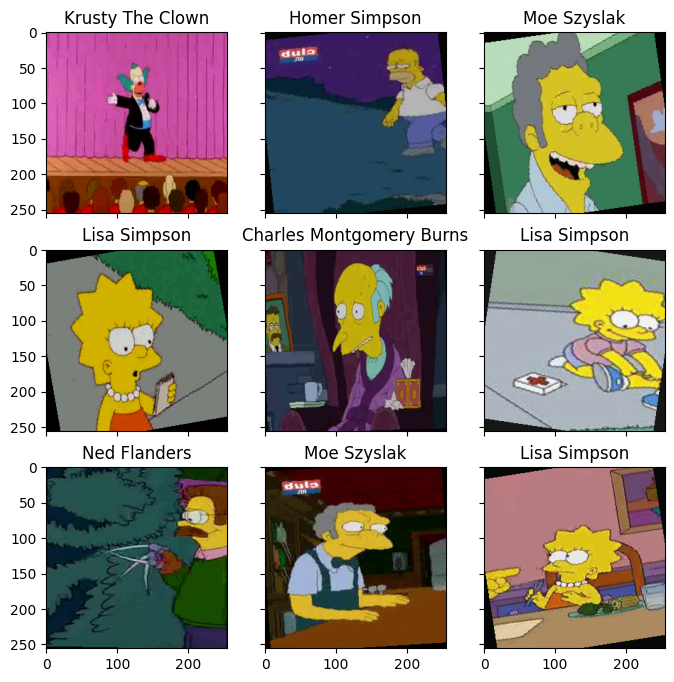

In [16]:
fig, ax = plt.subplots(nrows=3, ncols=3,figsize=(8, 8), \
                        sharey=True, sharex=True)
for fig_x in ax.flatten():
    random_characters = int(np.random.uniform(0, 4500))
    im_val, label = image_datasets['train'][random_characters]
    # inverse_transform это метод LabelEncoder(), мы закодировали цифрами классы, с помощью inverse_transform из чисел вернём название класса
    # получаем имя персонажа с заглавных букв
    img_label = " ".join(map(lambda x: x.capitalize(),\
                image_datasets['val'].label_encoder.inverse_transform([label])[0].split('_')))
    imshow(im_val.data.cpu(), \
          title=img_label,plt_ax=fig_x)

# CNN-модель с нуля

Здесь реализована сверточная нейросеть для классификации персонажей. Модель принимает трехканальное изображение размера `input_size x input_size` и возвращает логиты по всем классам.

Архитектура усилена residual-блоками: внутри каждого блока есть две свертки, batch normalization и skip connection. Это помогает глубокой CNN стабильнее обучаться и снижает риск деградации качества при увеличении числа слоев.

In [17]:
class ResidualBlock(nn.Module):
    """Сверточный residual-блок с проекцией skip-ветки при смене числа каналов."""

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )
        self.skip = nn.Identity()
        if in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        return F.relu(self.main(x) + self.skip(x))


class SimpsonsClassifier(nn.Module):
    """CNN-модель для классификации персонажей Симпсонов."""

    def __init__(self, input_size: int, num_classes: int):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.features = nn.Sequential(
            ResidualBlock(32, 64),
            nn.MaxPool2d(kernel_size=2),
            ResidualBlock(64, 128),
            nn.MaxPool2d(kernel_size=2),
            ResidualBlock(128, 256),
            nn.MaxPool2d(kernel_size=2),
            ResidualBlock(256, 256),
            nn.MaxPool2d(kernel_size=2),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)


In [18]:
def visualization(train, val, is_loss = True):

  if is_loss:
    plt.figure(figsize=(17,10))
    plt.plot(train, label = 'Training loss')
    plt.plot(val, label = 'Val loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

  else:
    plt.figure(figsize=(17,10))
    plt.plot(train, label = 'Training acc')
    plt.plot(val, label = 'Val acc')
    plt.title('Training and validation acc')
    plt.xlabel('Epochs')
    plt.ylabel('Acc')
    plt.legend()
    plt.show()

In [19]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=25):
    """
    Базовый цикл обучения и валидации PyTorch-модели с переносом на выбранное устройство (CPU/GPU).

    Параметры
    ----------
    model : torch.nn.Module
        Обучаемая модель.
    dataloaders : dict
        Словарь с двумя ключами: 'train' и 'val'.
        Каждое значение — это DataLoader для соответствующей выборки.
    criterion : torch.nn.Module
    optimizer : torch.optim.Optimizer
    num_epochs : int, optional
        Количество эпох обучения (по умолчанию 25).

    Возвращает
    ----------
    model : torch.nn.Module
        Обученная модель (с весами после последней эпохи).
    history_val : dict
        История валидации: {'loss': [...], 'acc': [...]} по эпохам.
    history_train : dict
        История обучения: {'loss': [...], 'acc': [...]} по эпохам.
    """
    # Автоматически определяем устройство
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Переносим модель на устройство
    model = model.to(device)

    history_val = {'loss': [], 'acc': []}
    history_train = {'loss': [], 'acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 20)

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0 # сюда складываем лосс для каждого сэмпла
            running_corrects = 0 # сюда складываем число верно угаданных (для подсчета accuracy)
            total = 0

            for inputs, labels in tqdm.tqdm(dataloaders[phase], desc=phase):
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                  outputs = model(inputs)
                  loss = criterion(outputs, labels)
                  _, predicted = outputs.max(1)

                  if phase == 'train':
                      loss.backward()
                      optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += predicted.eq(labels).sum().item()
                total += labels.size(0)



            epoch_loss = running_loss / total
            epoch_acc = 100.0 * running_corrects / total



            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                history_train['loss'].append(epoch_loss)
                history_train['acc'].append(epoch_acc)
            else:
                history_val['loss'].append(epoch_loss)
                history_val['acc'].append(epoch_acc)

        print()

    return model, history_val, history_train



In [20]:
model = SimpsonsClassifier(input_size[0], n_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Обучение CNN

Запускаю обучение baseline-модели, сохраняю историю loss/accuracy на train и validation, затем визуализирую динамику метрик.

In [21]:
model, history_val, history_train = train_model(model, dataloaders_dict, criterion, optimizer, num_epochs=15)

Using device: cuda
Epoch 1/15
--------------------


train: 100%|██████████| 458/458 [04:48<00:00,  1.59it/s]


train Loss: 2.8569 Acc: 19.6410


val: 100%|██████████| 197/197 [00:42<00:00,  4.66it/s]


val Loss: 2.4724 Acc: 31.9108

Epoch 2/15
--------------------


...

val Loss: 0.4196 Acc: 89.1879

Epoch 15/15
--------------------


train: 100%|██████████| 458/458 [04:51<00:00,  1.57it/s]


train Loss: 0.4884 Acc: 86.8764


val: 100%|██████████| 197/197 [00:41<00:00,  4.70it/s]

val Loss: 0.4317 Acc: 88.9650



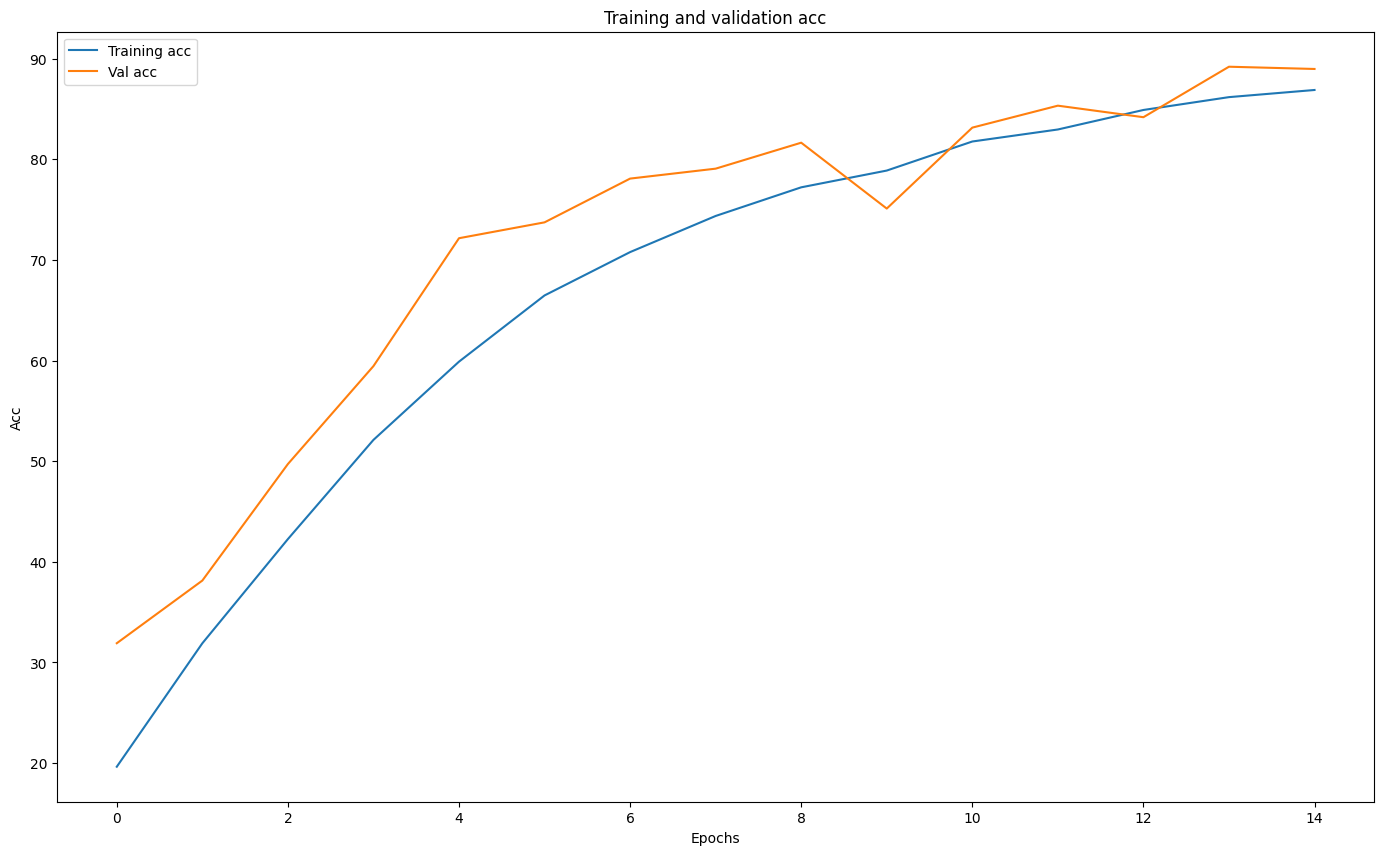

In [22]:
# смотрим точность в каждую из эпох на трейне и тесте
visualization(history_train["acc"], history_val["acc"], is_loss = False)

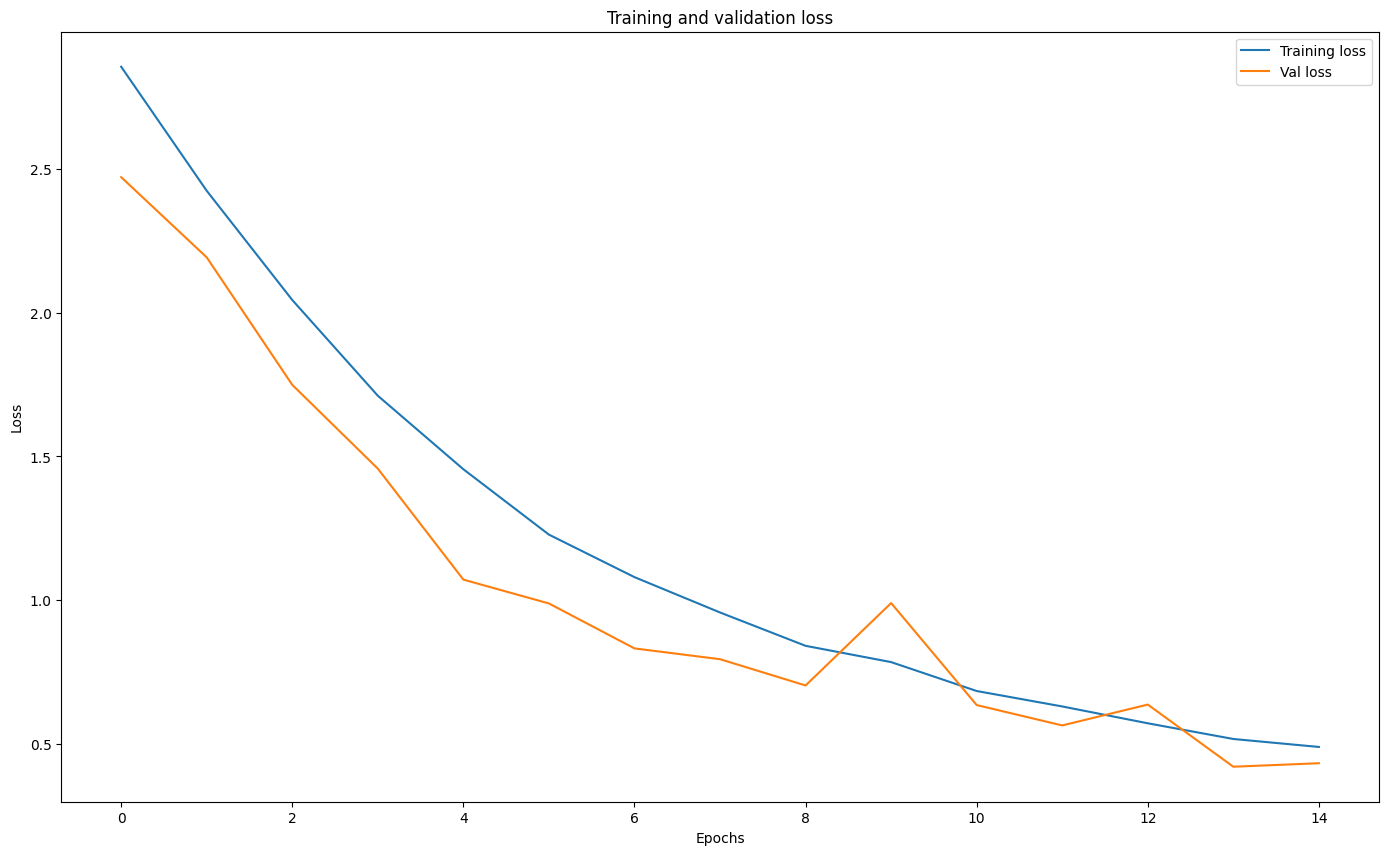

In [23]:
# смотрим лосс в каждую из эпох на трейне и тесте
visualization(history_train["loss"], history_val["loss"], is_loss = True)

In [24]:
def predict_one_sample(model, img_tensor, device=torch.device("cuda" if torch.cuda.is_available() else "cpu")) -> np.ndarray:
    """Возвращает numpy-массив вероятностей принадлежности изображения к каждому классу.
       Модель возвращает логиты, после чего применяется softmax.
    """
    model.eval()
    img_tensor = img_tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(img_tensor)
        logits = outputs.logits if hasattr(outputs, "logits") else outputs
        y_pred = torch.softmax(logits, dim=1)

    return y_pred.cpu().numpy().squeeze()

In [25]:
test_model = SimpsonsClassifier(input_size=64, num_classes=n_classes).to(torch.device("cuda"))

# Один фейковый образец
x = torch.randn(3, 64, 64).to(torch.device("cuda"))  # C x H x W

# 1. Проверка типа и формы выхода
probs = predict_one_sample(test_model, x)
assert isinstance(probs, np.ndarray), "Выход должен быть np.ndarray"
assert probs.shape == (n_classes,), f"Ожидалась форма ({n_classes},), а получили {probs.shape}"
print("Тест 1: форма и тип выхода корректны")

# 2. Проверка, что вероятности суммируются в 1
s = probs.sum()
assert np.isclose(s, 1.0, atol=1e-5), f"Сумма вероятностей должна быть 1, а сейчас {s}"
print("Тест 2: сумма вероятностей = 1")

# 3. Проверка, что нет отрицательных вероятностей
assert np.all(probs >= 0), "Вероятности не могут быть отрицательными"
print("Тест 3: все вероятности >= 0")

Тест 1: форма и тип выхода корректны
Тест 2: сумма вероятностей = 1
Тест 3: все вероятности >= 0


In [26]:
def predict(model, dataloader, device=torch.device("cuda" if torch.cuda.is_available() else "cpu")) -> np.ndarray:
    """Делает предсказания для всего даталоадера. Нужно проитерироваться по даталоадеру, получить предикты модели (только класс в виде числа, через argmax),
       сложить все предсказания в preds и вернуть мне его в виде np.ndarray.
    """
    model.eval()
    preds = []
    with torch.no_grad():
        for inputs, labels in tqdm.tqdm(dataloader, desc='Evaluating'):
          inputs, labels = inputs.to(device), labels.to(device)
          outputs = model(inputs)
          logits = outputs.logits if hasattr(outputs, "logits") else outputs
          _, predicted = logits.max(1)
          preds.append(predicted)

    preds = torch.cat(preds).cpu().numpy()
    return preds


def build_confusion_matrix(model, dataloader, true_labels, class_names, device):
    """
    Строит confusion matrix по предсказаниям модели и реальным меткам.
    """
    preds = predict(model, dataloader, device)
    cm = sk_confusion_matrix(true_labels, preds)

    plt.subplots(figsize=(20,20))
    sn.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="YlGnBu",
        linewidths=0.5,
        cbar=False,
        vmax = 30,
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()


Evaluating: 100%|██████████| 31/31 [00:06<00:00,  4.85it/s]


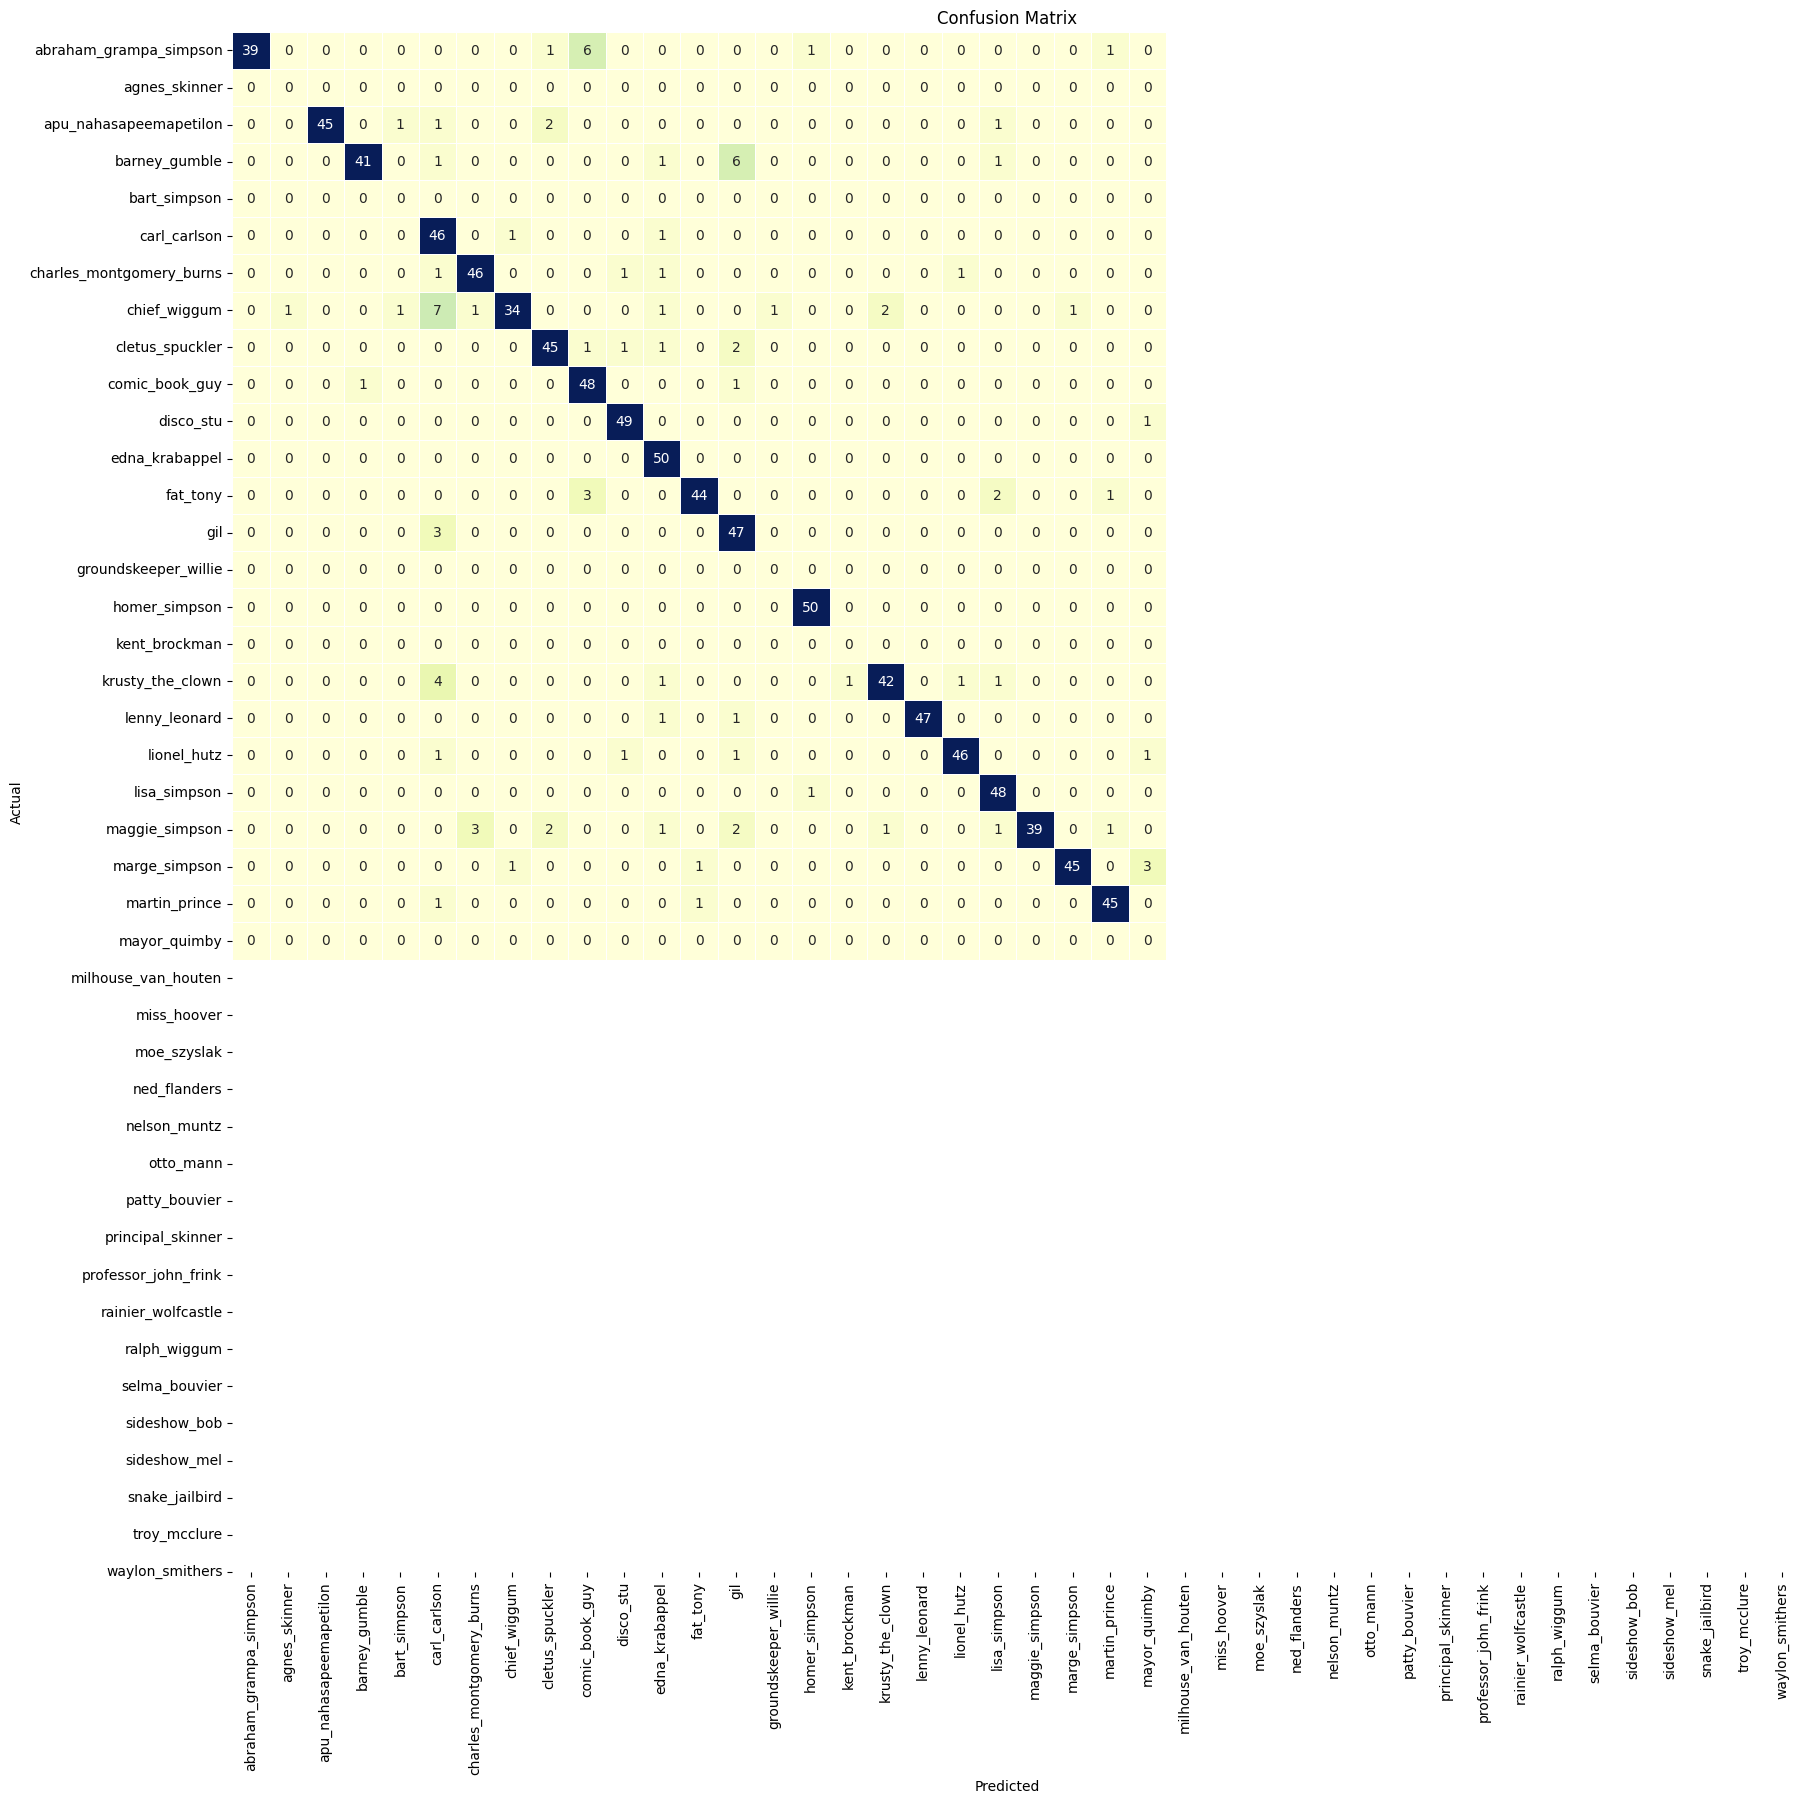

In [27]:
# Строим confusion_matrix
true_labels = [image_datasets_test[i][1] for i in range(len(image_datasets_test))]
build_confusion_matrix(model, dataloader_test, true_labels, image_datasets["train"].label_encoder.classes_, torch.device("cuda") if torch.cuda.is_available() else "cpu")

# Проверка предсказаний CNN

Визуализирую несколько случайных изображений из тестового набора и сравниваю истинные классы с предсказаниями модели.

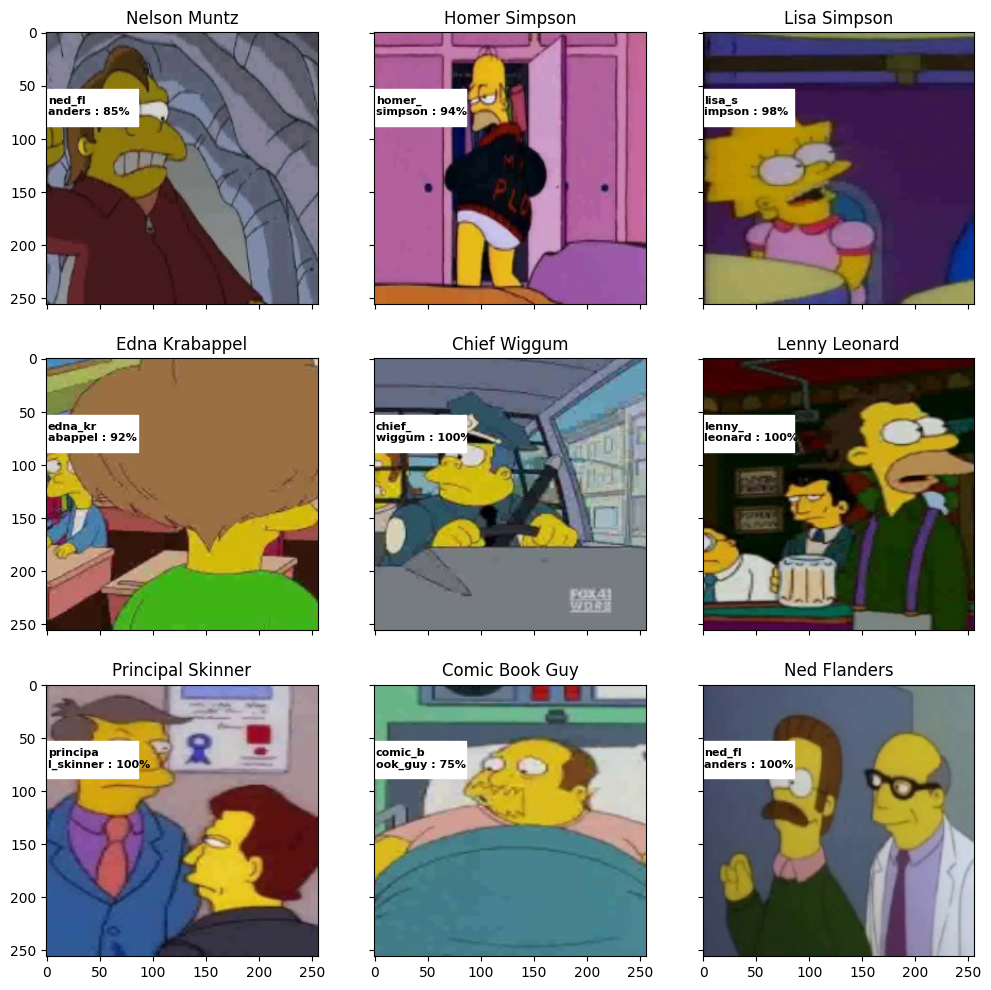

In [28]:
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties

fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(12, 12), \
                        sharey=True, sharex=True)

label_encoder = image_datasets["train"].label_encoder

for fig_x in ax.flatten():
    random_characters = int(np.random.uniform(0, 1000))
    im_val, label = image_datasets_test[random_characters]
    # inverse_transform это метод LabelEncoder(), мы закодировали цифрами классы, с помощью inverse_transform из чисел вернём название класса
    # получаем имя персонажа с заглавных букв
    img_label = " ".join(map(lambda x: x.capitalize(),\
                label_encoder.inverse_transform([label])[0].split('_')))

    imshow(im_val.data.cpu(), \
          title=img_label, plt_ax=fig_x)

    actual_text = "Actual : {}".format(img_label)

    # добавим область на которой будем выводить вероятность
    fig_x.add_patch(patches.Rectangle((0, 53), 86, 35, color='white'))
    font0 = FontProperties()
    font = font0.copy()
    prob_pred = predict_one_sample(model, im_val)
    # получаем вероятность
    predicted_proba = np.max(prob_pred)*100
    y_pred = np.argmax(prob_pred)

    predicted_label = label_encoder.classes_[y_pred]
    predicted_label = predicted_label[:len(predicted_label)//2] + '\n' + predicted_label[len(predicted_label)//2:]
    predicted_text = "{} : {:.0f}%".format(predicted_label,predicted_proba)

    fig_x.text(1, 59, predicted_text , horizontalalignment='left', fontproperties=font,
                    verticalalignment='top',fontsize=8, color='black',fontweight='bold')

# Transfer learning на ViT

Для сравнения с CNN использую предобученный Vision Transformer `google/vit-base-patch16-224`. Backbone уже обучался на ImageNet и умеет извлекать универсальные визуальные признаки.

В этом эксперименте замораживается большая часть модели, но дообучается не только классификационная голова: дополнительно размораживается последний encoder block и финальный layer norm. Для них используется меньший learning rate, чтобы аккуратно адаптировать признаки под персонажей Simpsons без сильного переобучения.

In [29]:
from transformers import ViTImageProcessor, ViTForImageClassification

# https://huggingface.co/google/vit-base-patch16-224
# Предобученный ViT используется как backbone для transfer learning.
model_name = "google/vit-base-patch16-224"
model_processor = ViTImageProcessor.from_pretrained(model_name)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

In [30]:
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=n_classes,
    ignore_mismatched_sizes=True
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([42])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([42, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [31]:
model

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [32]:
for name, param in model.named_parameters():
    param.requires_grad = (
        name.startswith("classifier")
        or name.startswith("vit.encoder.layer.11")
        or name.startswith("vit.layernorm")
    )

In [33]:
class SimpsonsDatasetWithProcessor(Dataset):
    def __init__(self, files_path, processor=model_processor, is_test=False, label_encoder=None):
        self.files_path = files_path
        self.processor = processor
        self.is_test = is_test

        if not is_test:
            self.labels_str = [p.parent.name for p in self.files_path]
        else:
            self.labels_str = [extract_label_from_filename(p.name) for p in self.files_path]

        if label_encoder is None:
            self.label_encoder = LabelEncoder()
            self.label_encoder.fit(self.labels_str)
        else:
            self.label_encoder = label_encoder

    def __len__(self):
        return len(self.files_path)

    def __getitem__(self, idx):
        img_path = self.files_path[idx]
        image = Image.open(img_path).convert("RGB")
        inputs = self.processor(images=image, return_tensors="pt")
        image = inputs["pixel_values"].squeeze(0)

        label_str = self.labels_str[idx]
        label = self.label_encoder.transform([label_str]).item()

        return image, label


In [34]:
image_datasets = {mode: SimpsonsDatasetWithProcessor(train_val_paths[mode]) for mode in ['train', 'val']}
image_datasets_test = SimpsonsDatasetWithProcessor(test_path, is_test=True, label_encoder=image_datasets["train"].label_encoder)

batch_size = 32
dataloaders_dict = {'train': torch.utils.data.DataLoader(image_datasets['train'], batch_size=batch_size, shuffle=True, num_workers=4),
                    'val': torch.utils.data.DataLoader(image_datasets['val'], batch_size=batch_size, shuffle=True, num_workers=4)}
dataloader_test = torch.utils.data.DataLoader(image_datasets_test, batch_size=batch_size, shuffle=False, num_workers=4)

In [35]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=25):
    """
    Базовый цикл обучения и валидации PyTorch-модели с переносом на выбранное устройство (CPU/GPU).

    Параметры
    ----------
    model : torch.nn.Module
        Обучаемая модель.
    dataloaders : dict
        Словарь с двумя ключами: 'train' и 'val'.
        Каждое значение — это DataLoader для соответствующей выборки.
    criterion : torch.nn.Module
        Функция потерь (например, nn.CrossEntropyLoss()).
    optimizer : torch.optim.Optimizer
        Оптимизатор (например, Adam или SGD).
    num_epochs : int, optional
        Количество эпох обучения (по умолчанию 25).

    Возвращает
    ----------
    model : torch.nn.Module
        Обученная модель (с весами после последней эпохи).
    history_val : dict
        История валидации: {'loss': [...], 'acc': [...]} по эпохам.
    history_train : dict
        История обучения: {'loss': [...], 'acc': [...]} по эпохам.
    """
    # Автоматически определяем устройство
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Переносим модель на устройство
    model = model.to(device)

    history_val = {'loss': [], 'acc': []}
    history_train = {'loss': [], 'acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 20)

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0 # сюда складываем лосс для каждого сэмпла
            running_corrects = 0 # сюда складываем число верно угаданных (для подсчета accuracy)
            total = 0

            for inputs, labels in tqdm.tqdm(dataloaders[phase], desc=phase):
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                  outputs = model(inputs)
                  logits = outputs.logits
                  loss = criterion(logits, labels)
                  _, predicted = logits.max(1)

                  if phase == 'train':
                      loss.backward()
                      optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += predicted.eq(labels).sum().item()
                total += labels.size(0)



            epoch_loss = running_loss / total
            epoch_acc = 100.0 * running_corrects / total


            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                history_train['loss'].append(epoch_loss)
                history_train['acc'].append(epoch_acc)
            else:
                history_val['loss'].append(epoch_loss)
                history_val['acc'].append(epoch_acc)

        print()

    return model, history_val, history_train



In [36]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    [
        {"params": model.classifier.parameters(), "lr": 3e-4},
        {"params": model.vit.encoder.layer[-1].parameters(), "lr": 1e-5},
        {"params": model.vit.layernorm.parameters(), "lr": 1e-5},
    ],
    weight_decay=1e-4
)

model, history_val, history_train = train_model(
    model, dataloaders_dict, criterion, optimizer, num_epochs=8
)

Using device: cuda
Epoch 1/8
--------------------


train: 100%|██████████| 458/458 [03:12<00:00,  2.37it/s]


train Loss: 2.1465 Acc: 46.7891


val: 100%|██████████| 197/197 [01:12<00:00,  2.72it/s]


val Loss: 1.3259 Acc: 70.2548

Epoch 2/8
--------------------


...

val Loss: 0.3251 Acc: 91.7197

Epoch 8/8
--------------------


train: 100%|██████████| 458/458 [03:12<00:00,  2.38it/s]


train Loss: 0.1459 Acc: 97.4271


val: 100%|██████████| 197/197 [01:12<00:00,  2.70it/s]

val Loss: 0.3067 Acc: 91.9904



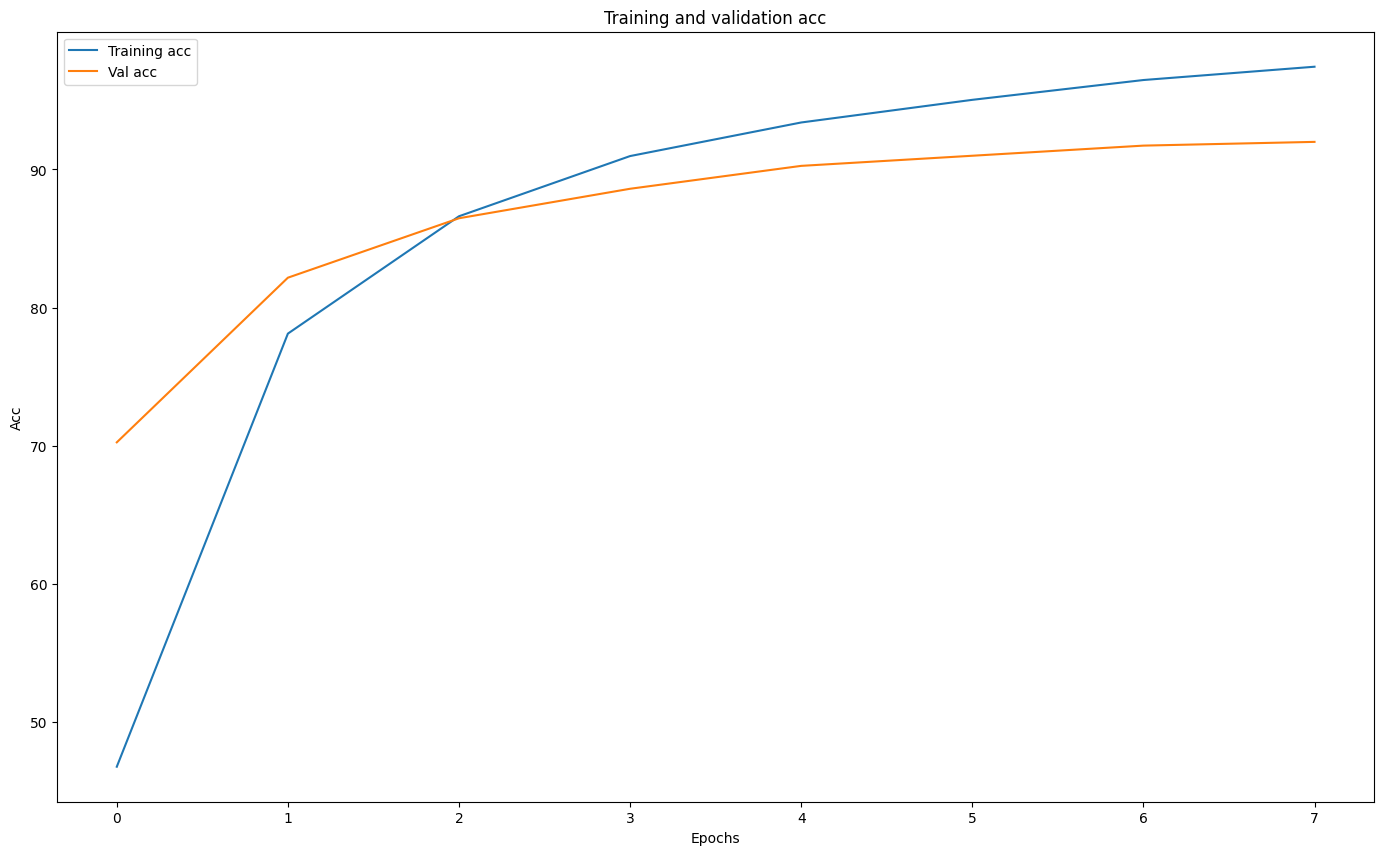

In [37]:
visualization(history_train["acc"], history_val["acc"], is_loss = False)

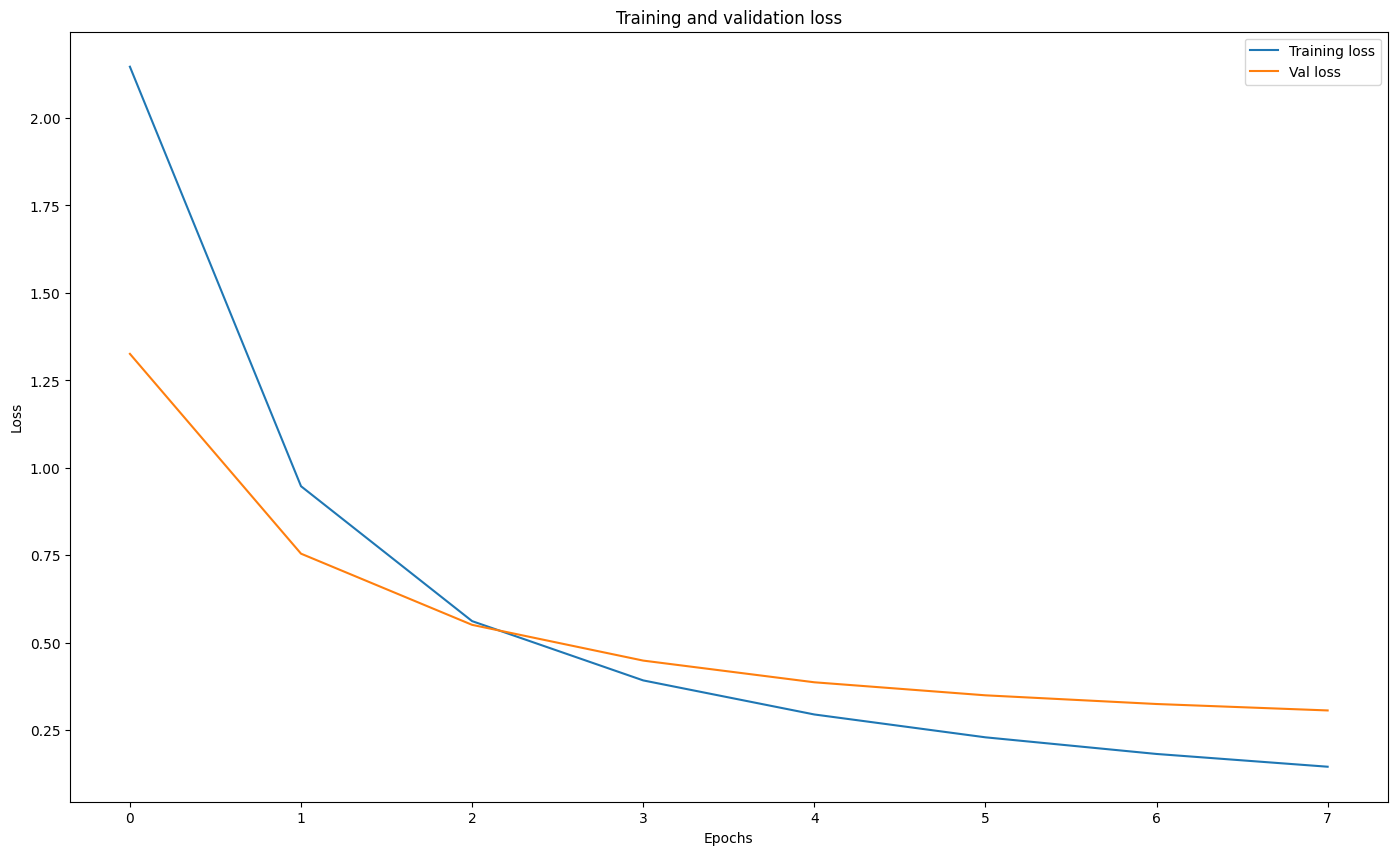

In [38]:
visualization(history_train["loss"], history_val["loss"], is_loss = True)

Evaluating: 100%|██████████| 31/31 [00:11<00:00,  2.78it/s]


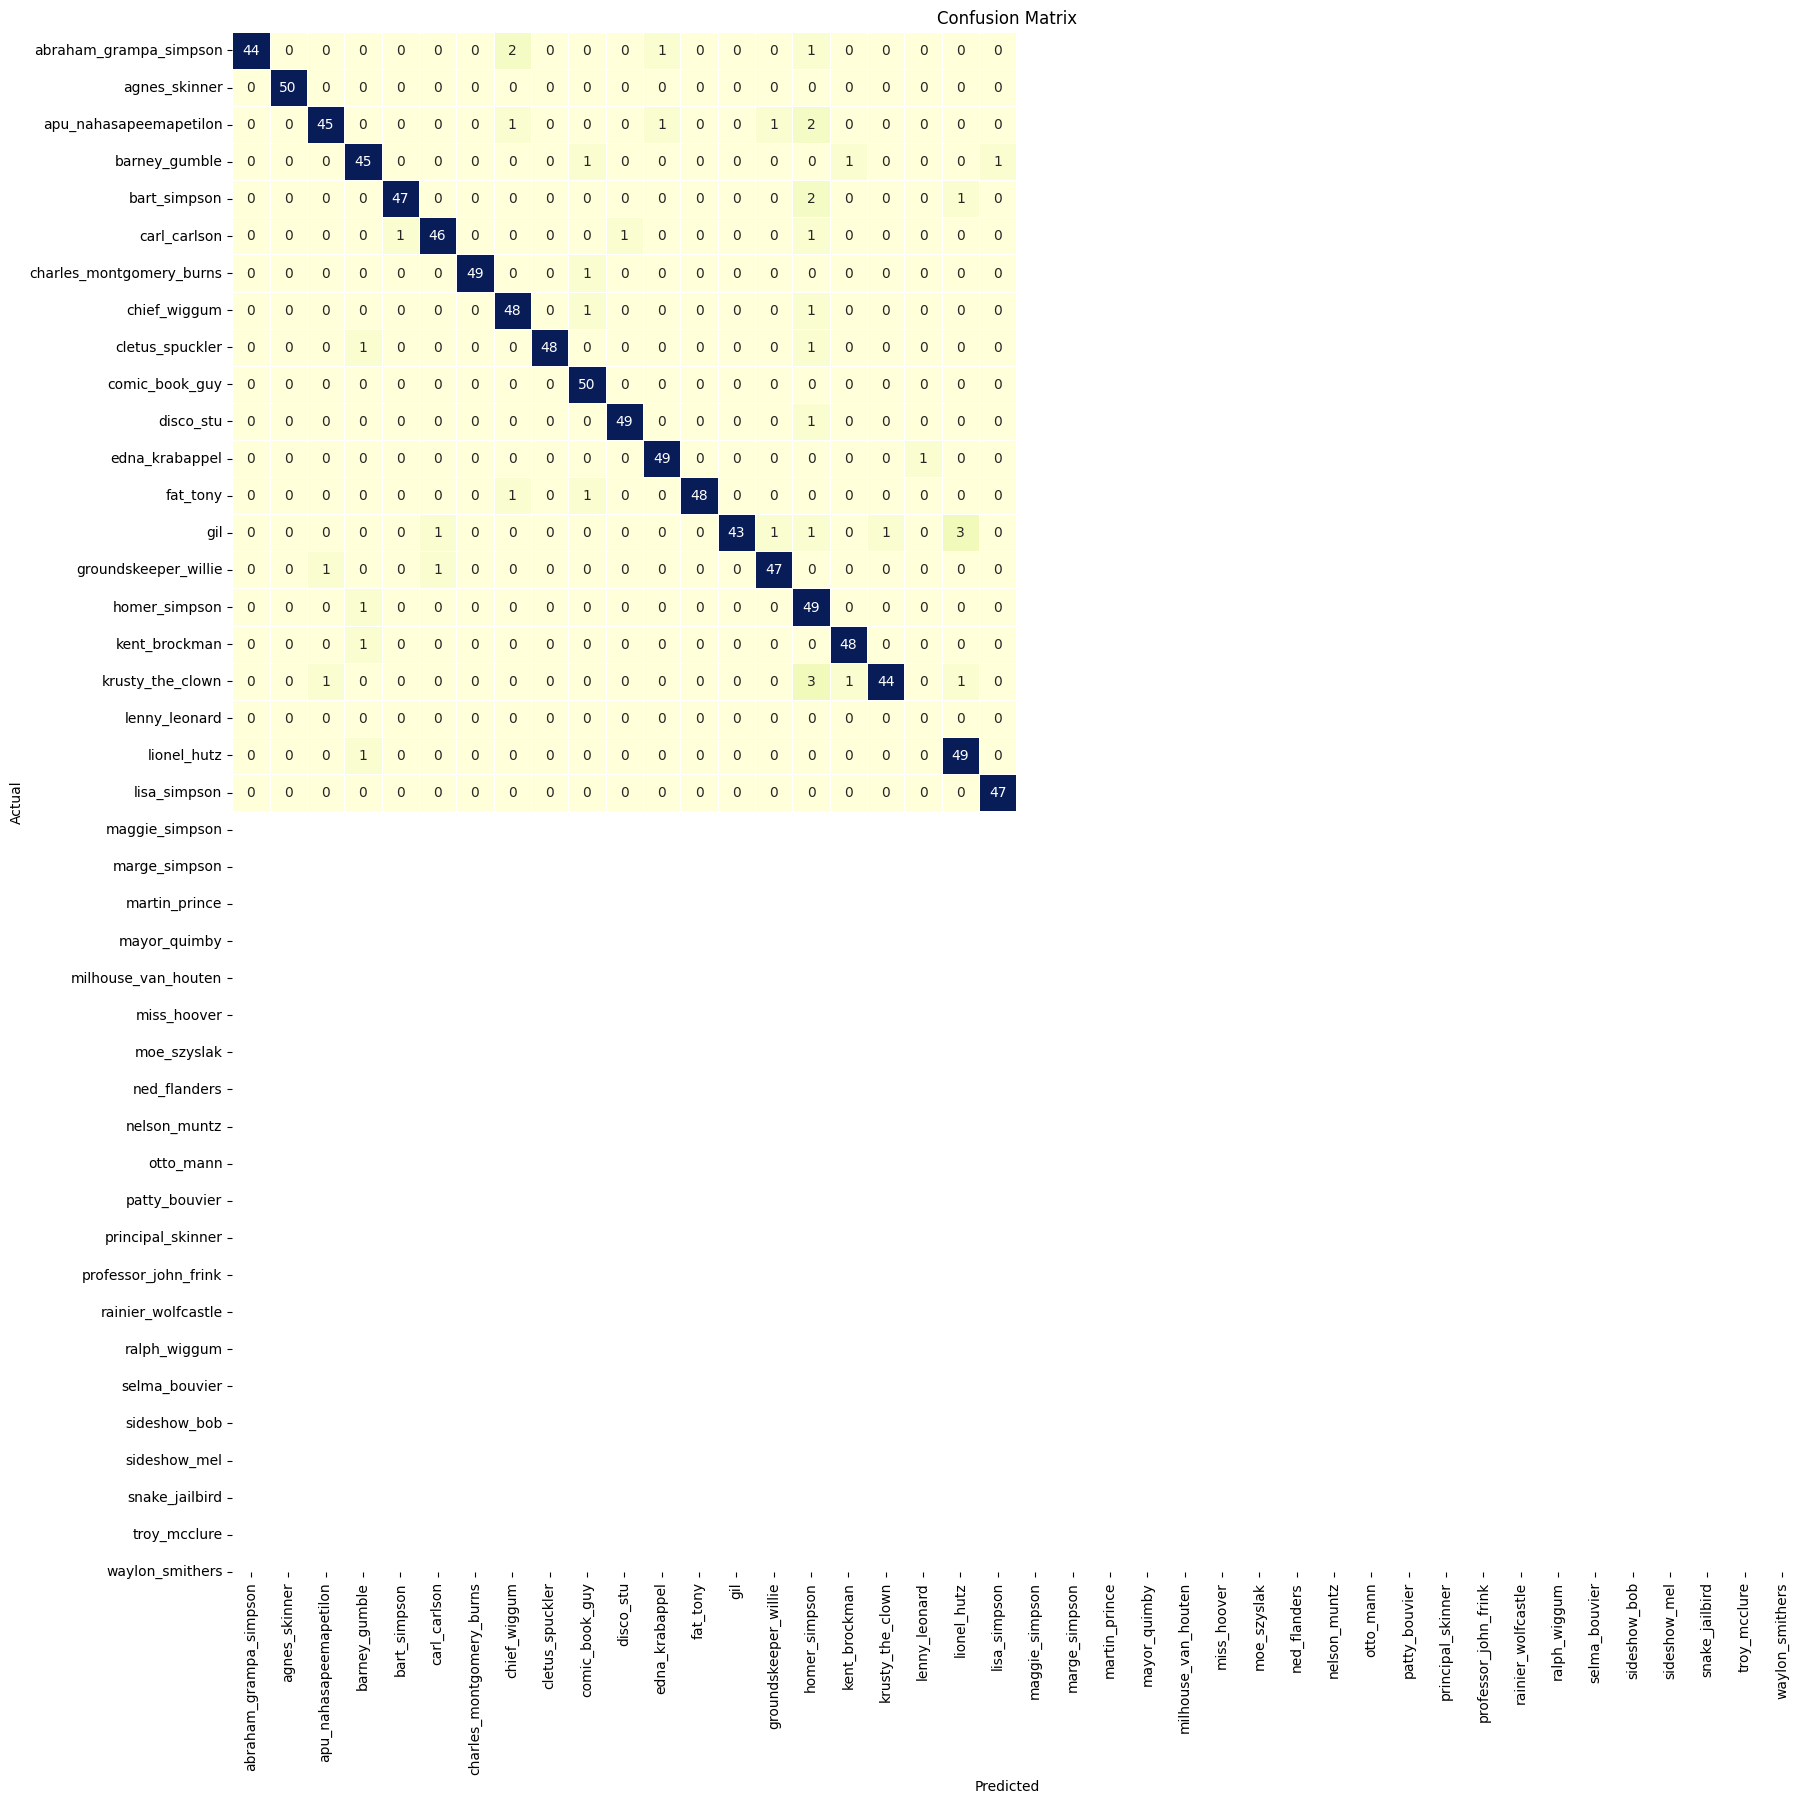

In [39]:
true_labels = [image_datasets_test[i][1] for i in range(len(image_datasets_test))]

# Визуализация confusion matrix для ViT-эксперимента.
build_confusion_matrix(
    model,
    dataloader_test,
    true_labels,
    image_datasets['train'].label_encoder.classes_,
    torch.device("cuda") if torch.cuda.is_available() else "cpu")

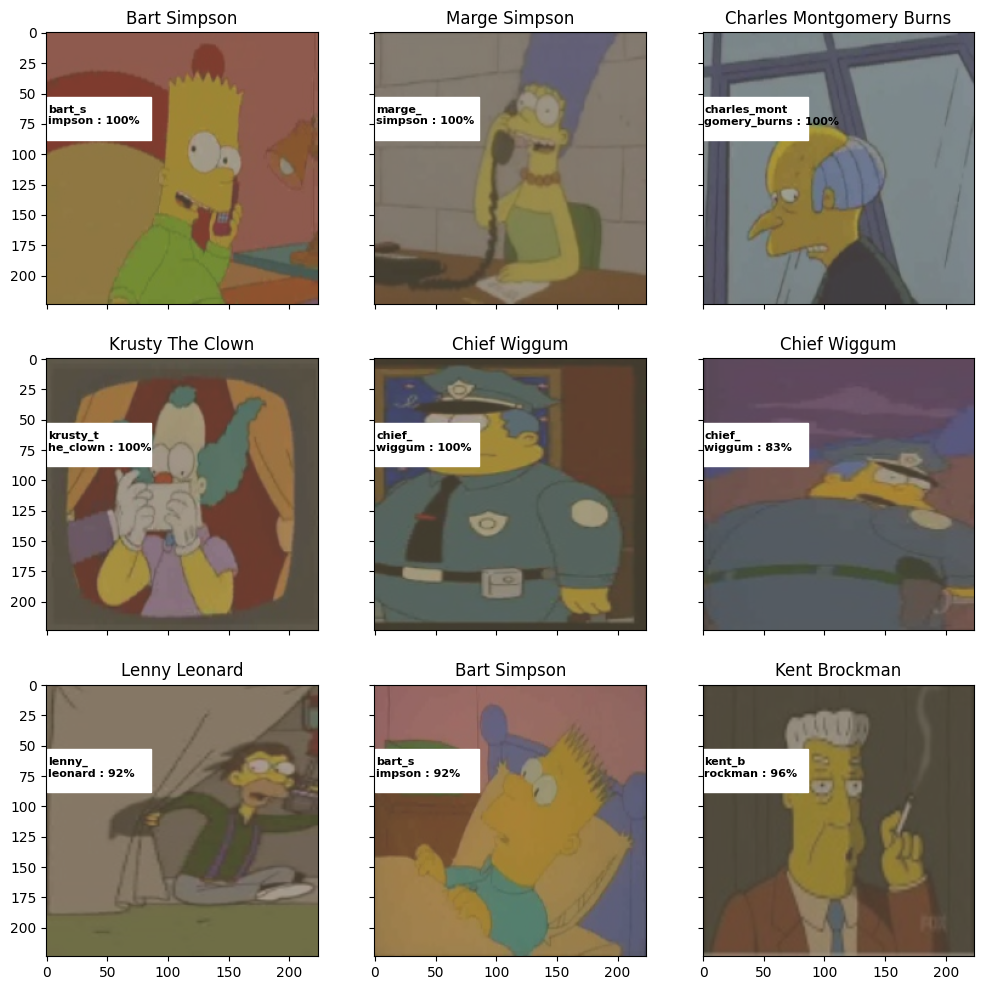

In [40]:
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties

fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(12, 12), \
                        sharey=True, sharex=True)

label_encoder = image_datasets['train'].label_encoder

for fig_x in ax.flatten():
    random_characters = int(np.random.uniform(0, 1000))
    im_val, label = image_datasets_test[random_characters]
    img_label = " ".join(map(lambda x: x.capitalize(),\
                label_encoder.inverse_transform([label])[0].split('_')))

    imshow(im_val.data.cpu(), \
          title=img_label, plt_ax=fig_x)

    actual_text = "Actual : {}".format(img_label)

    fig_x.add_patch(patches.Rectangle((0, 53), 86, 35, color='white'))
    font0 = FontProperties()
    font = font0.copy()
    prob_pred = predict_one_sample(model, im_val)
    predicted_proba = np.max(prob_pred)*100
    y_pred = np.argmax(prob_pred)

    predicted_label = label_encoder.classes_[y_pred]
    predicted_label = predicted_label[:len(predicted_label)//2] + '\n' + predicted_label[len(predicted_label)//2:]
    predicted_text = "{} : {:.0f}%".format(predicted_label,predicted_proba)

    fig_x.text(1, 59, predicted_text , horizontalalignment='left', fontproperties=font,
                    verticalalignment='top',fontsize=8, color='black',fontweight='bold')

# Итоги

В проекте собран end-to-end пайплайн классификации изображений: ручная реализация свертки, подготовка датасета, обучение собственной CNN, анализ ошибок через confusion matrix и эксперимент с transfer learning на ViT.

После первичного эксперимента были усилены места, которые сильнее всего влияют на качество: добавлена строгая валидация параметров свертки, CNN переведена на residual-блоки, в train-препроцессинг добавлены аугментации, а ViT дообучается с разморозкой последнего encoder block и отдельными learning rate для backbone/head.

Возможные следующие шаги: подобрать learning rate scheduler, провести grid search по learning rate и weight decay, сравнить несколько backbone-моделей и отдельно проверить fine-tuning последних 2-3 блоков ViT.